# Model SVM
## 1. Environment Setup and Library Imports

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef, make_scorer, accuracy_score

# Set project root directory
PROJECT_ROOT = r"C:\Users\b1795\Desktop\Laboratory2_SP"

DATA_RAW_DIR = os.path.join(PROJECT_ROOT, "data_raw")
DATA_PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data_processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")

os.makedirs(MODEL_DIR, exist_ok=True)
print("Environment setup completed.")

Environment setup completed.


## 2. Helper Functions (FASTA Loading)

In [10]:
def load_fasta_dict(fasta_path):
    """Read a FASTA file and return a dictionary {Accession: Sequence}"""
    seqs = {}
    header = None
    seq = []
    if not os.path.exists(fasta_path):
        raise FileNotFoundError(f"FASTA file not found: {fasta_path}")
    with open(fasta_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header:
                    seqs[header] = "".join(seq)
                header = line[1:].split()[0]
                seq = []
            else:
                seq.append(line)
        if header:
            seqs[header] = "".join(seq)
    return seqs

print("Helper function definition completed.")

Helper function definition completed.


## 3. Data Loading (Sequences and Datasets)

In [11]:
print("Loading protein sequences:")
seq_dict_pos = load_fasta_dict(os.path.join(DATA_RAW_DIR, "positive.fasta"))
seq_dict_neg = load_fasta_dict(os.path.join(DATA_RAW_DIR, "negative.fasta"))
# Merge positive and negative sequence dictionaries
seq_dict_all = {**seq_dict_pos, **seq_dict_neg}

print("Loading TSV tables:")
# Train Set (with Fold information)
df_train = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "training_with_fold_info.tsv"), sep="\t")

# Benchmark Set (Positive + Negative)
df_bench_pos = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "benchmark_positive.tsv"), sep="\t")
df_bench_neg = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "benchmark_negative.tsv"), sep="\t")

# Assign labels to benchmark sets and merge
df_bench_pos['label'] = 1
df_bench_neg['label'] = 0
df_bench = pd.concat([df_bench_pos, df_bench_neg], ignore_index=True)

print(f"Data loading completed:")
print(f"- Number of training samples: {len(df_train)}")
print(f"- Number of benchmark samples: {len(df_bench)}")

Loading protein sequences:
Loading TSV tables:
Data loading completed:
- Number of training samples: 18840
- Number of benchmark samples: 4710


## 4. Feature Extraction Function Definition
- Extract the first 22 amino acids + the hydrophobicity of the first 40 amino acids.

In [12]:
# Kyte–Doolittle hydrophobicity scale
HYDRO_SCALE = {
    "A": 1.8, "C": 2.5, "D": -3.5, "E": -3.5, "F": 2.8, "G": -0.4, "H": -3.2, 
    "I": 4.5, "K": -3.9, "L": 3.8, "M": 1.9, "N": -3.5, "P": -1.6, "Q": -3.5, 
    "R": -4.5, "S": -0.8, "T": -0.7, "V": 4.2, "W": -0.9, "Y": -1.3
}
AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")

def extract_features(sequence):
    """
    Extract features for a single sequence:
    1. AA Composition (first 22 residues) -> 20 dimensions
    2. Hydrophobicity (average and maximum of first 40 residues) -> 2 dimensions
    Total: 22 features.
    """
    features = []
    
    # Feature 1: Amino acid composition (first 22 residues)
    seq_22 = sequence[:22]
    len_22 = len(seq_22)
    counter = Counter(seq_22)
    
    for aa in AA_ORDER:
        # Compute frequency
        freq = counter[aa] / len_22 if len_22 > 0 else 0
        features.append(freq)
        
    # Feature 2: Hydrophobicity (first 40 residues)
    seq_40 = sequence[:40]
    hydro_vals = [HYDRO_SCALE.get(aa, 0) for aa in seq_40]
    
    if len(hydro_vals) > 0:
        avg_hydro = np.mean(hydro_vals)
        max_hydro = np.max(hydro_vals)
    else:
        avg_hydro = 0
        max_hydro = 0
        
    features.append(avg_hydro)
    features.append(max_hydro)
    
    return np.array(features)

print("Feature extraction function defined.")

Feature extraction function defined.


## 5. Feature Matrix Construction

In [13]:
def build_feature_matrix(df, seq_dict):
    X = []
    y = []
    
    for idx, row in df.iterrows():
        acc = row['accession']
        if acc in seq_dict:
            seq = str(seq_dict[acc])
            # Extract features
            features = extract_features(seq)
            X.append(features)
            y.append(int(row['label']))
            
    return np.array(X), np.array(y)

print("Extracting training set features:")
X_train, y_train = build_feature_matrix(df_train, seq_dict_all)

print("Extracting benchmark set features:")
X_bench, y_bench = build_feature_matrix(df_bench, seq_dict_all)

print(f"Feature matrix construction completed.")
print(f"- X_train shape: {X_train.shape} (should be N x 22)")

Extracting training set features:
Extracting benchmark set features:
Feature matrix construction completed.
- X_train shape: (18840, 22) (should be N x 22)


## 6. Feature Selection (Random Forest)
- Use Random Forest to automatically select important features.

Starting feature selection:
Original number of features: 22
Number of selected features: 3


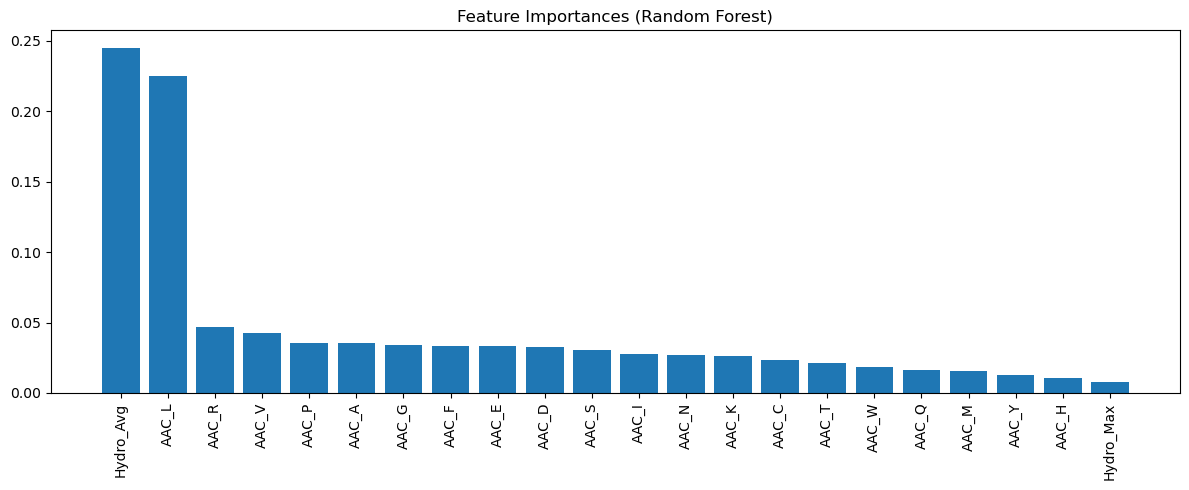

In [14]:
print("Starting feature selection:")

# Feature standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Benchmark data must be transformed using training-set parameters only
X_bench_scaled = scaler.transform(X_bench)

# Train Random Forest to evaluate feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# Select features based on importance (keep features above the mean importance)
selector = SelectFromModel(rf, threshold="mean", prefit=True)
X_train_sel = selector.transform(X_train_scaled)
X_bench_sel = selector.transform(X_bench_scaled)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of selected features: {X_train_sel.shape[1]}")

# Plot feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feat_names = [f"AAC_{aa}" for aa in AA_ORDER] + ["Hydro_Avg", "Hydro_Max"]

plt.figure(figsize=(12, 5))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [feat_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

## 7. SVM Model Optimization (Grid Search)
- Optimize C and gamma using grid search to maximize MCC.

In [16]:
print("Starting SVM grid search optimization:")

# Define hyperparameter grid
param_grid = {
    'C': [0.1, 1, 2, 4, 8, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1, 2],
    'kernel': ['rbf']
}

# Define evaluation metric: MCC
mcc_scorer = make_scorer(matthews_corrcoef)

# Run grid search (with internal 5-fold cross-validation)
grid = GridSearchCV(
    SVC(probability=True, random_state=42), 
    param_grid, 
    cv=5, 
    scoring=mcc_scorer, 
    n_jobs=-1, 
    verbose=1
)

grid.fit(X_train_sel, y_train)

print(f"\nBest parameters: {grid.best_params_}")
print(f"Best CV MCC: {grid.best_score_:.3f}")

Starting SVM grid search optimization:
Fitting 5 folds for each of 42 candidates, totalling 210 fits

Best parameters: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Best CV MCC: 0.675


## 8. Final Evaluation (Benchmark)

In [17]:
print("Final Benchmark Evaluation (SVM)")

# Use the optimized best model
best_svm = grid.best_estimator_

# Prediction
y_pred = best_svm.predict(X_bench_sel)

# Compute evaluation metrics
acc = accuracy_score(y_bench, y_pred)
mcc = matthews_corrcoef(y_bench, y_pred)
cm = confusion_matrix(y_bench, y_pred)

print(f"Accuracy: {acc:.3f}")
print(f"MCC:      {mcc:.3f}")
print("\nConfusion Matrix:")
print(cm)
print("\nDetailed classification report:")
print(classification_report(y_bench, y_pred))

print("\nSVM completed.")

Final Benchmark Evaluation (SVM)
Accuracy: 0.938
MCC:      0.699

Confusion Matrix:
[[4015  108]
 [ 186  401]]

Detailed classification report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      4123
           1       0.79      0.68      0.73       587

    accuracy                           0.94      4710
   macro avg       0.87      0.83      0.85      4710
weighted avg       0.93      0.94      0.94      4710


SVM completed.
